In [ ]:
import numpy as np
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV


# Load Data

In [ ]:
# 載入 iris 資料集
iris = load_iris()
df = pd.DataFrame(iris["data"], columns=iris["feature_names"])
df["target"] = iris["target"]

# 預處理

In [ ]:
# Label Encoding
le = LabelEncoder()
df["target"] = le.fit_transform(df["target"])

In [ ]:
# 切分資料集
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# 特徵縮放
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 建立, 訓練, 評估模型

In [ ]:
# 評估模型(混淆矩陣,分類報告)
def evaluate_model(model, X_train, y_train, X_test, y_test):
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)
  print("Train Set:")
  print(classification_report(y_train, y_train_pred))
  print("Test Set:")
  print(classification_report(y_test, y_test_pred))
  # 計算 AUC 多分類
  train_auc = roc_auc_score(y_train, model.predict_proba(X_train), multi_class='ovr')
  test_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')
  print(f"Train AUC: {train_auc:.6f}")
  print(f"Test AUC: {test_auc:.6f}")
  # 混淆矩陣
  plt.figure(figsize=(7, 4))
  plt.subplot(1, 2, 1)
  sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, cmap='Blues', fmt='d', cbar=False)
  plt.title('Confusion Matrix (Train Set)')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.subplot(1, 2, 2)
  sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, cmap='Blues', fmt='d', cbar=False)
  plt.title('Confusion Matrix (Test Set)')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.tight_layout()
  plt.show()


====== LR model ======
Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.97      0.97      0.97        35
           2       0.97      0.97      0.97        35

    accuracy                           0.98       105
   macro avg       0.98      0.98      0.98       105
weighted avg       0.98      0.98      0.98       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Train AUC: 0.999456
Test AUC: 0.995556


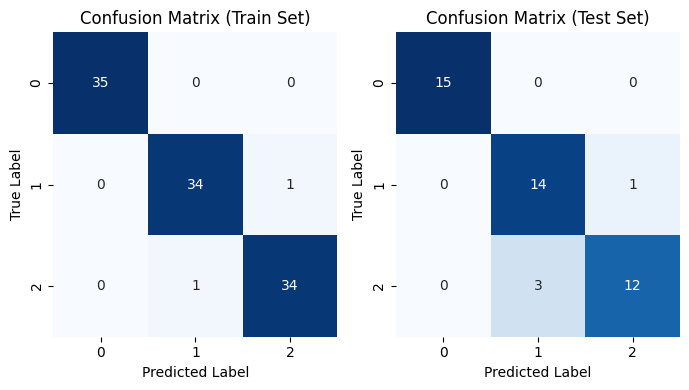

====== RF model ======
Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        35

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.78      0.93      0.85        15
           2       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45

Train AUC: 1.000000
Test AUC: 0.993333


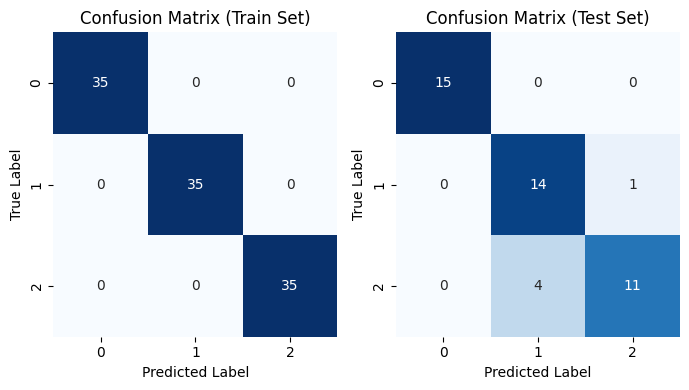

====== SVM model ======
Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.97      0.94      0.96        35
           2       0.94      0.97      0.96        35

    accuracy                           0.97       105
   macro avg       0.97      0.97      0.97       105
weighted avg       0.97      0.97      0.97       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

Train AUC: 0.999456
Test AUC: 0.995556


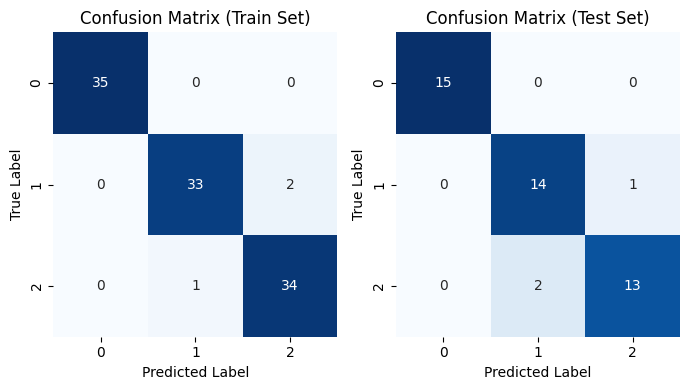

====== DT model ======
Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        35

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.93      0.97        15
           2       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45

Train AUC: 1.000000
Test AUC: 0.983333


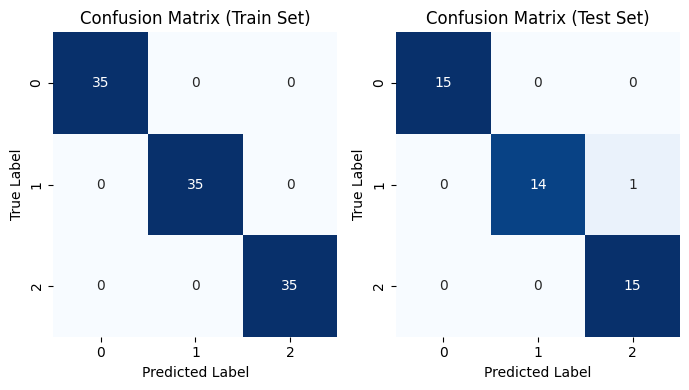

====== KNN model ======
Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.97      0.97      0.97        35
           2       0.97      0.97      0.97        35

    accuracy                           0.98       105
   macro avg       0.98      0.98      0.98       105
weighted avg       0.98      0.98      0.98       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.79      1.00      0.88        15
           2       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45

Train AUC: 0.996871
Test AUC: 0.988889


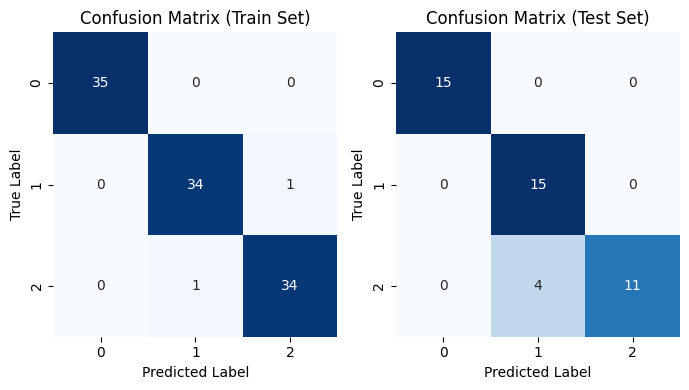

In [ ]:
# 建立模型（LR, RF, SVM, DT, KNN）
models = {
    "LR model": LogisticRegression(max_iter=1000),
    "RF model": RandomForestClassifier(),
    "SVM model": SVC(probability=True),
    "DT model": DecisionTreeClassifier(),
    "KNN model": KNeighborsClassifier()
}

# 訓練
for name, model in models.items():
  print(f"====== {name} ======")
  model.fit(X_train_scaled, y_train)
  evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test)

# 交叉驗證

In [ ]:
# K次交叉驗證/平均分數
print("\nK-Fold Cross-Validation (k=5) 每折詳細結果")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
  print(f"\n======== {name} ========")
  accs, precisions, recalls, f1s = [], [], [], []
  fold = 1
  for train_idx, val_idx in cv.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    # 標準化
    scaler = StandardScaler()
    X_train_cv = scaler.fit_transform(X_train_cv)
    X_val_cv = scaler.transform(X_val_cv)
    model.fit(X_train_cv, y_train_cv)
    y_pred = model.predict(X_val_cv)

    # 混淆矩陣
    cm = confusion_matrix(y_val_cv, y_pred)
    acc = accuracy_score(y_val_cv, y_pred)
    precision = precision_score(y_val_cv, y_pred, average='macro')
    recall = recall_score(y_val_cv, y_pred, average='macro')
    f1 = f1_score(y_val_cv, y_pred, average='macro')

    print(f"。Fold {fold}:\n{cm}")
    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

    accs.append(acc)
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)
    fold += 1


K-Fold Cross-Validation (k=5) 每折詳細結果

======== LR model ========
。Fold 1:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
。Fold 2:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]
Accuracy: 0.9667, Precision: 0.9697, Recall: 0.9667, F1: 0.9666
。Fold 3:
[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]
Accuracy: 0.9000, Precision: 0.9024, Recall: 0.9000, F1: 0.8997
。Fold 4:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
。Fold 5:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]
Accuracy: 0.9000, Precision: 0.9024, Recall: 0.9000, F1: 0.8997

======== RF model ========
。Fold 1:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
。Fold 2:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]
Accuracy: 0.9667, Precision: 0.9697, Recall: 0.9667, F1: 0.9666
。Fold 3:
[[10  0  0]
 [ 0  8  2]
 [ 0  0 10]]
Accuracy: 0.9333, Precision: 0.9444, Recall: 0.9333, F1: 0.9327
。Fold 4:
[[10  0  0]
 [ 0 

# 網格搜索

In [ ]:
# GridSearchCV 找出最佳參數
param_grid = {
    'RF model': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 10, None]
    },
    'SVM model': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf']
    },
    'KNN model': {
        'n_neighbors': [3, 5, 7, 9]
    }
}

for name in param_grid:
  print(f"\nGrid Search for {name}")
  model = models[name]
  clf = GridSearchCV(model, param_grid[name], cv=5, scoring='accuracy')
  clf.fit(X_train_scaled, y_train)
  print(f"Best Params: {clf.best_params_}")
  print(f"Best Score: {clf.best_score_:.4f}")




Grid Search for RF model
Best Params: {'max_depth': 3, 'n_estimators': 50}
Best Score: 0.9619

Grid Search for SVM model
Best Params: {'C': 0.1, 'kernel': 'linear'}
Best Score: 0.9714

Grid Search for KNN model
Best Params: {'n_neighbors': 7}
Best Score: 0.9619


# 匯出, 整理表格

In [ ]:
# results = []

# for name, model in models.items():
#   print(f"Processing {name}...")
#   model.fit(X_train_scaled, y_train)
#   y_pred = model.predict(X_test_scaled)
#   y_proba = model.predict_proba(X_test_scaled)

#   # Confusion Matrix
#   cm = confusion_matrix(y_test, y_pred)
#   # 評估指標
#   accuracy = accuracy_score(y_test, y_pred)
#   precision = precision_score(y_test, y_pred, average='weighted')
#   recall = recall_score(y_test, y_pred, average='weighted')
#   f1 = f1_score(y_test, y_pred, average='weighted')
#   auc = roc_auc_score(y_test, y_proba, multi_class='ovr')

#   # 5-Fold Cross Validation
#   pipeline = make_pipeline(StandardScaler(), model)
#   cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
#   cv_mean = cv_scores.mean()

#   # Grid Search
#   best_params = "-"
#   best_score = "-"
#   if name in param_grid:
#       gs = GridSearchCV(model, param_grid[name], cv=5, scoring='accuracy')
#       gs.fit(X_train_scaled, y_train)
#       best_params = str(gs.best_params_)
#       best_score = gs.best_score_

#   results.append({
#       "Model": name,
#       "Accuracy": accuracy,
#       "Precision": precision,
#       "Recall": recall,
#       "F1 Score": f1,
#       "AUC": auc,
#       "CrossVal Mean Acc (k=5)": cv_mean,
#       "Best Params": best_params,
#       "Best GridSearch Score": best_score,
#       "Confusion Matrix": cm.tolist()
#   })

# # 匯出為 Excel
# result_df = pd.DataFrame(results)

# with pd.ExcelWriter("model_results.xlsx", engine='openpyxl') as writer:
#   result_df.drop(columns=["Confusion Matrix"]).to_excel(writer, sheet_name="Metrics", index=False)

#   for row in results:
#       cm_df = pd.DataFrame(row["Confusion Matrix"], index=iris.target_names, columns=iris.target_names)
#       cm_df.to_excel(writer, sheet_name=f"{row['Model'][:28]} CM")
